In [57]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from matplotlib.colors import PowerNorm
import numpy as np

### MUESTRA DE DATOS

# 100K DATASET

In [2]:

#100K
links_100K = pd.read_csv('BBDD_100K/links.csv')
movies_100K = pd.read_csv('BBDD_100K/movies.csv')
ratings_100K = pd.read_csv('BBDD_100K/ratings.csv')
tags_100K = pd.read_csv('BBDD_100K/tags.csv')

In [3]:
print(links_100K.head())
'''
movieId: ID de la película (de MovieLens).
imdbId: ID de la película en IMDb.
tmdbId: ID de la película en TMDb.
'''

   movieId  imdbId   tmdbId
0        1  114709    862.0
1        2  113497   8844.0
2        3  113228  15602.0
3        4  114885  31357.0
4        5  113041  11862.0


'\nmovieId: ID de la película (de MovieLens).\nimdbId: ID de la película en IMDb.\ntmdbId: ID de la película en TMDb.\n'

In [4]:
print(movies_100K.head())
print(movies_100K.shape)
'''
movieId: ID de la película.
title: Título de la película, incluyendo el año.
genres: Lista de géneros separados por "|".
'''

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
(9742, 3)


'\nmovieId: ID de la película.\ntitle: Título de la película, incluyendo el año.\ngenres: Lista de géneros separados por "|".\n'

Estos son los géneros que tenemos

In [5]:
unique_genres = set('|'.join(movies_100K['genres']).split('|'))
# Mostrar géneros únicos
print(unique_genres)

{'Musical', 'Romance', 'Mystery', 'Fantasy', 'Horror', 'Western', 'Animation', 'IMAX', '(no genres listed)', 'Film-Noir', 'Sci-Fi', 'Documentary', 'Children', 'Crime', 'Action', 'War', 'Comedy', 'Adventure', 'Thriller', 'Drama'}


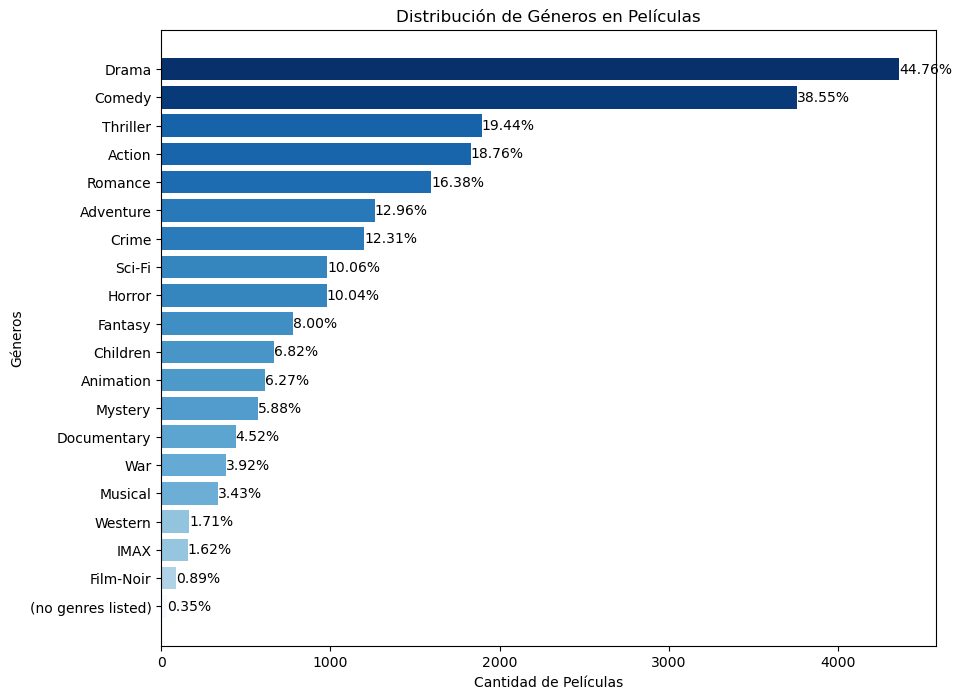

In [6]:
# Ampliamos la simulación a más filas para representar correctamente los datos
df = pd.concat([movies_100K]*2000, ignore_index=True).head(9742)

# Dividimos los géneros y los contamos
df['genres'] = df['genres'].str.split('|')
genre_count = df.explode('genres')['genres'].value_counts()

# Calculamos los porcentajes
genre_percentage = (genre_count / len(df)) * 100

# Graficamos
plt.figure(figsize=(10, 8))
norm = PowerNorm(gamma=0.26, vmin=min(genre_count), vmax=max(genre_count))
colors = plt.cm.Blues(norm(genre_count))
bars = plt.barh(genre_percentage.index, genre_count, color=colors)

# Añadimos las etiquetas con el porcentaje en cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f'{(width/len(df))*100:.2f}%', va='center')

# Configuración de ejes y título
plt.xlabel('Cantidad de Películas')
plt.ylabel('Géneros')
plt.title('Distribución de Géneros en Películas')
plt.gca().invert_yaxis()  # Descendente
plt.show()

In [7]:
print(ratings_100K.head())
print(ratings_100K.shape)
'''
userId: ID del usuario.
movieId: ID de la película.
rating: Calificación de la película en una escala de 0.5 a 5.0.
timestamp: Momento en que se hizo la calificación.
'''

   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
(100836, 4)


'\nuserId: ID del usuario.\nmovieId: ID de la película.\nrating: Calificación de la película en una escala de 0.5 a 5.0.\ntimestamp: Momento en que se hizo la calificación.\n'

In [8]:
print(tags_100K.head())
print(tags_100K.shape)
'''
userId: ID del usuario.
movieId: ID de la película.
tag: Etiqueta asignada.
timestamp: Momento en que se añadió la etiqueta.
'''

   userId  movieId              tag   timestamp
0       2    60756            funny  1445714994
1       2    60756  Highly quotable  1445714996
2       2    60756     will ferrell  1445714992
3       2    89774     Boxing story  1445715207
4       2    89774              MMA  1445715200
(3683, 4)


'\nuserId: ID del usuario.\nmovieId: ID de la película.\ntag: Etiqueta asignada.\ntimestamp: Momento en que se añadió la etiqueta.\n'

Estos son los tags mas utilizados

In [9]:
tag_tags = tags_100K.groupby(by='tag')
tag_tags['movieId'].count().sort_values(ascending=False).head(10).rename('n. of movies')

tag
In Netflix queue     131
atmospheric           36
thought-provoking     24
superhero             24
Disney                23
surreal               23
funny                 23
religion              22
dark comedy           21
sci-fi                21
Name: n. of movies, dtype: int64

### DATOS CONCRETOS

In [10]:
df_100K = ratings_100K.copy()
df_100K.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


Cuantos usuarios, peliculas y ratings tenemos?

Usuarios

In [11]:
df_100K['userId'].unique()

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

610 usuarios en total

In [12]:
len(df_100K['userId'].unique())

610

Cuantas películas tenemos?

In [13]:
df_100K['movieId'].unique()

array([     1,      3,      6, ..., 160836, 163937, 163981], dtype=int64)

9724 películas en total 

In [14]:
len(df_100K['movieId'].unique())

9724

Cual es la cantidad de veces que se ha votado a cada película? Y su valoración promedio?

In [15]:
movie_ratings = df_100K.groupby(by='movieId')
most_rated = movie_ratings['rating'].count().sort_values(ascending=False).head(10)
top_rated = movie_ratings['rating'].mean().where(movie_ratings['rating'].count() > 20).sort_values(ascending=False).head(10)
print(pd.merge(pd.DataFrame(most_rated), movies_100K, on='movieId')[['title','rating']].rename(index=lambda x: x+1, columns={'rating': 'Número de valoraciones'}),'\n')
print(pd.merge(pd.DataFrame(top_rated), movies_100K, on='movieId')[['title','rating']].rename(index=lambda x: x+1, columns={'rating': 'Promedio de Valoraciones'}))

                                        title  Número de valoraciones
1                         Forrest Gump (1994)                     329
2            Shawshank Redemption, The (1994)                     317
3                         Pulp Fiction (1994)                     307
4            Silence of the Lambs, The (1991)                     279
5                          Matrix, The (1999)                     278
6   Star Wars: Episode IV - A New Hope (1977)                     251
7                        Jurassic Park (1993)                     238
8                           Braveheart (1995)                     237
9           Terminator 2: Judgment Day (1991)                     224
10                    Schindler's List (1993)                     220 

                                            title  Promedio de Valoraciones
1                Shawshank Redemption, The (1994)                  4.429022
2   Sunset Blvd. (a.k.a. Sunset Boulevard) (1950)                  4.333333


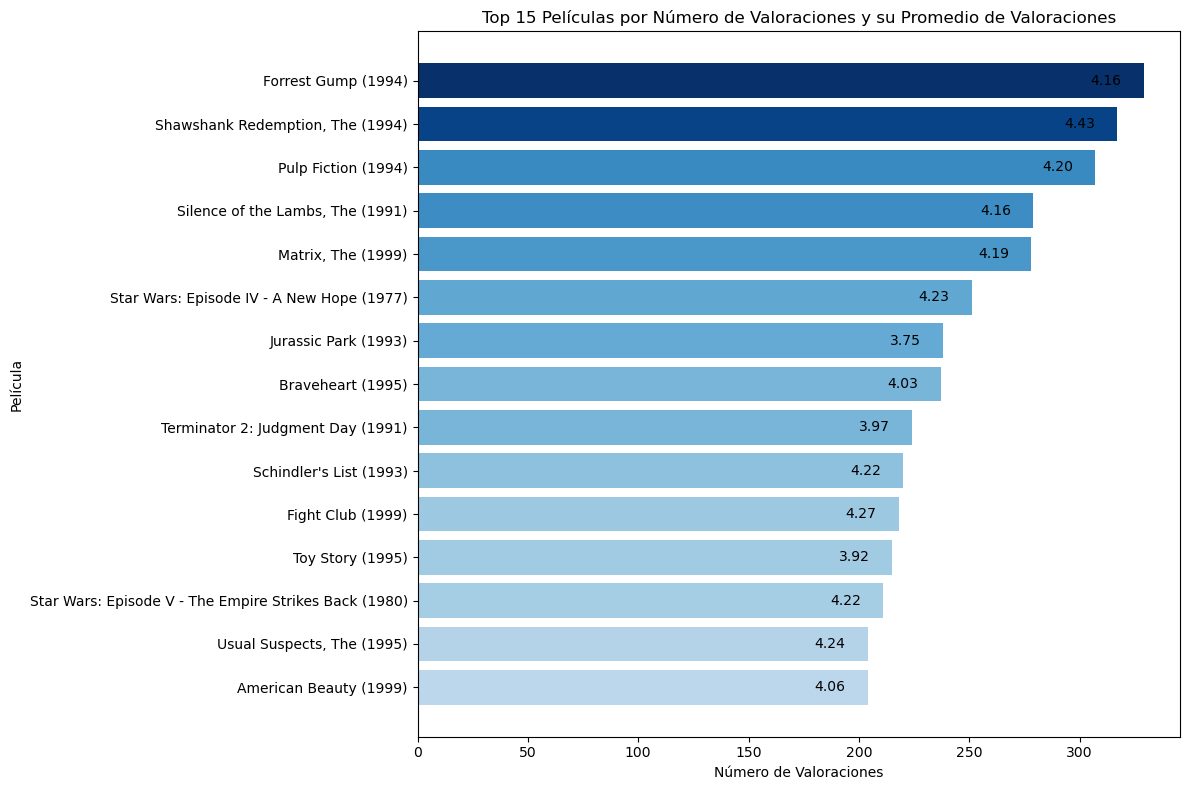

In [16]:
# Agrupar por movieId para obtener el número de valoraciones y el promedio de cada película
movie_ratings = ratings_100K.groupby(by='movieId')
most_rated = movie_ratings['rating'].count().sort_values(ascending=False).head(15)  # Películas más votadas
top_rated = movie_ratings['rating'].mean()  # Promedio de valoraciones de todas las películas

# Unir las listas de 'most_rated' con el dataframe de 'movies_100K'
most_rated_df = pd.merge(pd.DataFrame(most_rated), movies_100K, on='movieId')[['movieId', 'title', 'rating']].rename(columns={'rating': 'Número de valoraciones'})

# Unir las valoraciones promedio para las películas más votadas
most_rated_df = pd.merge(most_rated_df, pd.DataFrame(top_rated), on='movieId').rename(columns={'rating': 'Promedio de Valoraciones'})


plt.figure(figsize=(12, 8))
norm = PowerNorm(gamma=0.5, vmin=min(genre_count), vmax=max(genre_count))
colors = plt.cm.Blues(norm(genre_count))
bars = plt.barh(most_rated_df['title'], most_rated_df['Número de valoraciones'], color=colors)

# Añadir promedios
for index, bar in enumerate(bars):
    plt.text(bar.get_width() - 10, bar.get_y() + bar.get_height() / 2,
             f"{most_rated_df['Promedio de Valoraciones'].iloc[index]:.2f}", 
             va='center', ha='right', fontsize=10, color='black')

plt.xlabel('Número de Valoraciones')
plt.ylabel('Película')
plt.title('Top 15 Películas por Número de Valoraciones y su Promedio de Valoraciones')
plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

In [17]:
df_100K['rating'].head()

0    4.0
1    4.0
2    4.0
3    5.0
4    5.0
Name: rating, dtype: float64

Las valoraciones van desde los 0.5 a 5

In [18]:
print("Min rating = "+str(df_100K['rating'].min()))
print("Max rating = "+str(df_100K['rating'].max()))

Min rating = 0.5
Max rating = 5.0


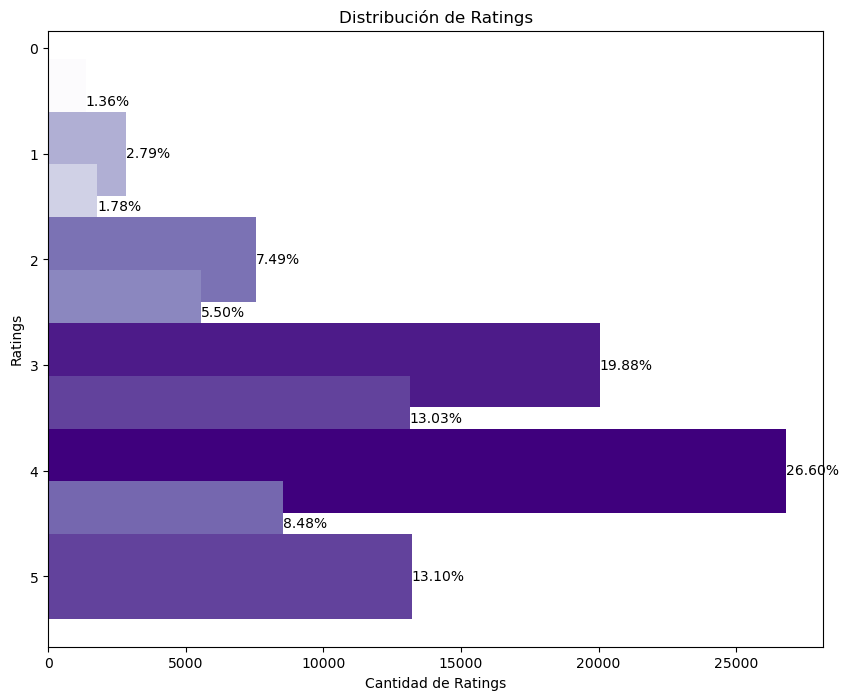

In [19]:
df_ratings = pd.concat([ratings_100K]*2000, ignore_index=True).head(100836)

rating_count = df_ratings['rating'].value_counts().sort_index() # Contamos cuántas veces aparece cada rating
rating_percentage = (rating_count / len(df_ratings)) * 100 # Calculamos los porcentajes

norm = PowerNorm(gamma=0.3, vmin=min(rating_count), vmax=max(rating_count))
colors = plt.cm.Purples(norm(rating_count))

plt.figure(figsize=(10, 8))
bars = plt.barh(rating_percentage.index, rating_count, color=colors)

#Añadir porcentaje
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f'{(width/len(df_ratings))*100:.2f}%', va='center')

plt.xlabel('Cantidad de Ratings')
plt.ylabel('Ratings')
plt.title('Distribución de Ratings')
plt.gca().invert_yaxis()  # Descendente
plt.show()

El usuario que mas ratings ha puesto ha valorado 2698 películas, el que menos 20

In [20]:
ratings_count_per_user = df_100K.groupby('userId')['rating'].count()

max_ratings = ratings_count_per_user.max()
min_ratings = ratings_count_per_user.min()

print(f"Máximo de ratings por usuario: {max_ratings}")
print(f"Mínimo de ratings por usuario: {min_ratings}")

Máximo de ratings por usuario: 2698
Mínimo de ratings por usuario: 20


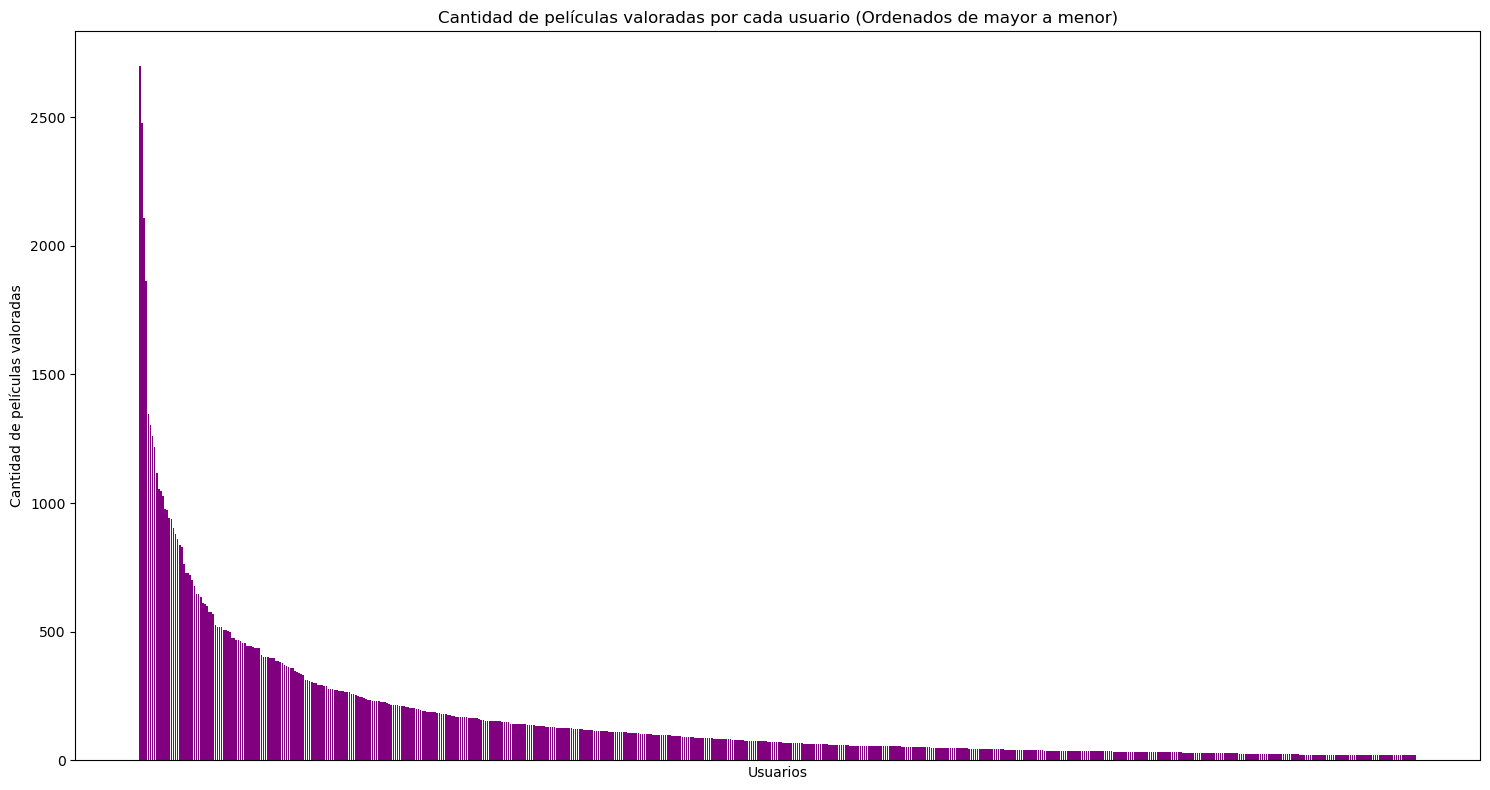

In [58]:
user_ratings = ratings_100K.groupby('userId')['rating'].count()
user_ratings_sorted = user_ratings.sort_values(ascending=False)
plt.figure(figsize=(15, 8))
plt.bar(np.arange(len(user_ratings_sorted)), user_ratings_sorted.values, color='purple')

plt.xlabel('Usuarios')
plt.ylabel('Cantidad de películas valoradas')
plt.title('Cantidad de películas valoradas por cada usuario (Ordenados de mayor a menor)')
plt.xticks([]) 

plt.tight_layout()
plt.show()


In [22]:
user_votes = df_100K.groupby('userId')['movieId'].count()

mean_votes_per_user = user_votes.mean() # Calculamos la media

print(f'El promedio de películas valoradas por los usuarios es: {mean_votes_per_user:.0f}')

El promedio de películas valoradas por los usuarios es: 165


100836 valoraciones distintas

In [23]:
len(df_100K['rating'])

100836

Tenemos valores nulos?

In [24]:
df_100K['userId'].isnull().sum()

0

In [25]:
df_100K['rating'].isnull().sum()

0

In [26]:
df_100K['movieId'].isnull().sum()

0

No hay valores nulos

### Pequeño resumen (BBDD 100K)

Tenemos una base de datos con 610 usuarios y 9724 películas, donde cada usuario ha votado como minimo 20 películas y el que mas 2698, con un total de 100836 valoraciones, sin valores nulos y con ratings que van desde 0.5 a 5 de puntuación.

## VISUALIZACIÓN DE LA ESCASEZ DE DATOS

Para visualizar el problema de la escasez de datos voy a crear la matriz de ratings de usuarios y películas

In [27]:
indice=list(df_100K['userId'].unique())
columnas=list(df_100K['movieId'].unique())
indice=sorted(indice)
columnas=sorted(columnas)
 
escasez_100K=pd.pivot_table(data=df_100K,values='rating',index='userId',columns='movieId')

In [28]:
escasez_100K

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,2.5,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
607,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
608,2.5,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
# Contar el número total de NaN en la matriz de escasez
total_nan = escasez_100K.isna().sum().sum()

print(f"Número total de valores NaN: {total_nan}")


Número total de valores NaN: 5830804


En total tenemos 5,8M de valores NULOS en nuestra matriz

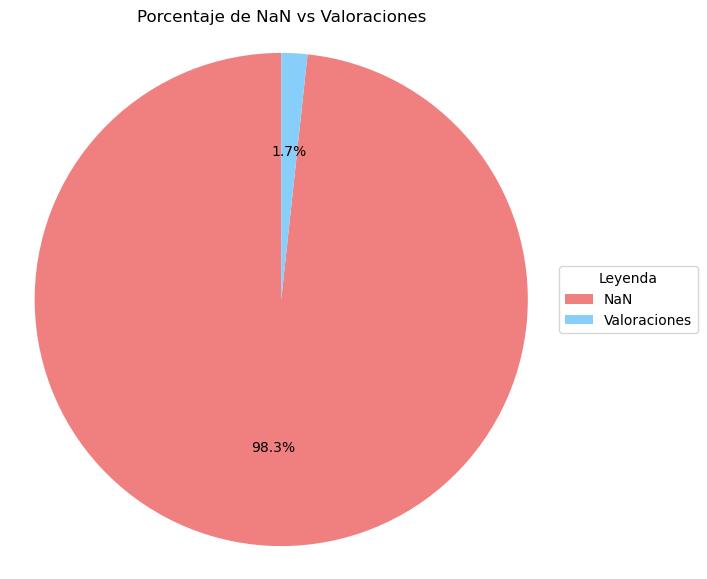

In [30]:
# Valores para el gráfico
total_valores = 610 * 9724  # Tamaño total de la tabla (usuarios x películas)
total_valoraciones = total_valores - total_nan  # El resto son valoraciones válidas

# Porcentajes
labels = ['NaN', 'Valoraciones']
sizes = [total_nan, total_valoraciones]
colors = ['lightcoral', 'lightskyblue']  # Colores para el gráfico

# Crear el gráfico de pie (quesito)
plt.figure(figsize=(7, 7))
plt.pie(sizes, autopct='%1.1f%%', startangle=90, colors=colors)

# Añadir la leyenda
plt.legend(labels, loc="center left", bbox_to_anchor=(1, 0.5), title="Leyenda")
plt.axis('equal')
plt.title('Porcentaje de NaN vs Valoraciones')

plt.show()

El porcentaje de valores nulos es muy grande, habrá que transformarlos con factorización de matrices para estimar valores con los que se pueda trabajar.